In [1]:
from copy import deepcopy
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
from matplotlib import ticker
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
from scipy.stats import t as student_t


class RegressionModel:
    def fit(self, x, y):
        raise NotImplementedError

    def predict(self, x):
        raise NotImplementedError

    def interval(self, x, confidence=0.95, kind="mean"):
        return None


class LinearRegression(RegressionModel):
    def fit(self, x, y):
        x, y = np.asarray(x, float), np.asarray(y, float)
        if len(x) < 3 or x.shape != y.shape or not (np.isfinite(x).all() and np.isfinite(y).all()):
            raise ValueError("Для регрессии нужны хотя бы три конечные пары x/y")
        self.n = len(x)
        self.x_mean = x.mean()
        self.y_mean = y.mean()
        centered_x = x - self.x_mean
        self.sxx = centered_x @ centered_x
        if self.sxx <= 0:
            raise ValueError("Нельзя построить регрессию при постоянном X")
        self.slope = centered_x @ (y - self.y_mean) / self.sxx
        self.residual_variance = np.sum((y - self.predict(x)) ** 2) / (self.n - 2)
        return self

    def predict(self, x):
        return self.y_mean + self.slope * (np.asarray(x) - self.x_mean)

    def interval(self, x, confidence=0.95, kind="mean"):
        if not 0 < confidence < 1:
            raise ValueError("confidence должен быть между 0 и 1")
        if kind not in ("mean", "prediction"):
            raise ValueError("kind: mean или prediction")
        x = np.asarray(x)
        variance = 1 / self.n + (x - self.x_mean) ** 2 / self.sxx
        if kind == "prediction":
            variance += 1
        half = student_t.ppf((1 + confidence) / 2, self.n - 2) * np.sqrt(self.residual_variance * variance)
        center = self.predict(x)
        return center - half, center + half


In [2]:
DATA_FILE = "horse_colic.csv"
FEATURES = ["rectal_temperature", "pulse", "respiratory_rate", "packed_cell_volume"]
HUE = "outcome"
OUTPUT_FILE = "scatterplot.png"
SHOW_PLOT = True
TITLE = "Horse colic · clinical measurements"

SCALE = "linear"
SCALE_BY_FEATURE = {}
AUTO_SCALE_RATIO = 8.0
SYMLOG_LINTHRESH = 1.0
LOG_BASE = 10
AXIS_MARGIN = 0.06
LIMITS_BY_FEATURE = {}
LABELS_BY_FEATURE = {"rectal_temperature": "Temperature, °C", "pulse": "Pulse, bpm", "respiratory_rate": "Resp. rate, /min", "packed_cell_volume": "Packed cell volume, %"}
TICKS_BY_FEATURE = {}


PANEL_SIZE = 2.8
FIGURE_DPI = 120
SAVE_DPI = 220
FIGURE_COLOR = "white"
FONT_FAMILY = "DejaVu Sans"
FONT_STRETCH = "condensed"
TITLE_SIZE = 18
LABEL_SIZE = 13
TICK_LABEL_SIZE = 10
FONT_COLOR = "#203047"
SPINE_COLOR = "#263c53"
SPINE_WIDTH = 2.2
SPINES_VISIBLE = {"left": True, "right": True, "top": True, "bottom": True}
MAJOR_TICK_COUNT = 4
MAJOR_TICK_LENGTH = 9
MAJOR_TICK_WIDTH = 1.0
MINOR_TICK_SUBDIVISIONS = 2
MINOR_TICK_LENGTH = 4
MINOR_TICK_WIDTH = 0.6
TICK_DIRECTION = "out"
TICK_LABEL_ROTATION = 0
TICK_LABEL_PADDING = 5
TICK_TOP = False
TICK_RIGHT = False
PANEL_GAP = 0.10


MAJOR_GRID = True
MINOR_GRID = False
GRID_COLOR = "#dbe3eb"
GRID_WIDTH = 0.7
GRID_ALPHA = 0.7
GRID_STYLE = "--"
MINOR_GRID_COLOR = "#edf1f5"
SCATTER_SIZE = 24
SCATTER_MARKER = "o"
SCATTER_ALPHA = 0.57
SCATTER_COLOR = "#2374ab"
SCATTER_EDGE_COLOR = "white"
SCATTER_EDGE_WIDTH = 0.3
PALETTE = ["#2374ab", "#dc6b57", "#48a182", "#a879bf"]
GROUP_STYLES = {}


DIAGONAL = "hist"
HIST_BINS = 18
HIST_COLOR = "#4f7fa8"
HIST_ALPHA = 0.8
HIST_EDGE_COLOR = "white"
HIST_EDGE_WIDTH = 0.6


DRAW_REGRESSION = True
REGRESSION_MODELS = {}
CONFIDENCE = 0.95
INTERVAL_KIND = "mean"
FIT_SPACE = "data"
REGRESSION_POINTS = 160
LINE_COLOR = "#ca513f"
LINE_WIDTH = 2.1
LINE_STYLE = "-"
BAND_COLOR = "#e88c76"
BAND_ALPHA = 0.18
PAIR_OPTIONS = {}
CUSTOM_BANDS = {}


LEGEND = True
LEGEND_COLUMNS = 4
LEGEND_FONT_SIZE = 11
LEGEND_MARKER_SIZE = 7
TRANSPARENT = False


Сохранено: C:\Users\bazdi\Desktop\TSR\scatterplot.png
Масштабы: rectal_temperature=linear, pulse=linear, respiratory_rate=linear, packed_cell_volume=linear


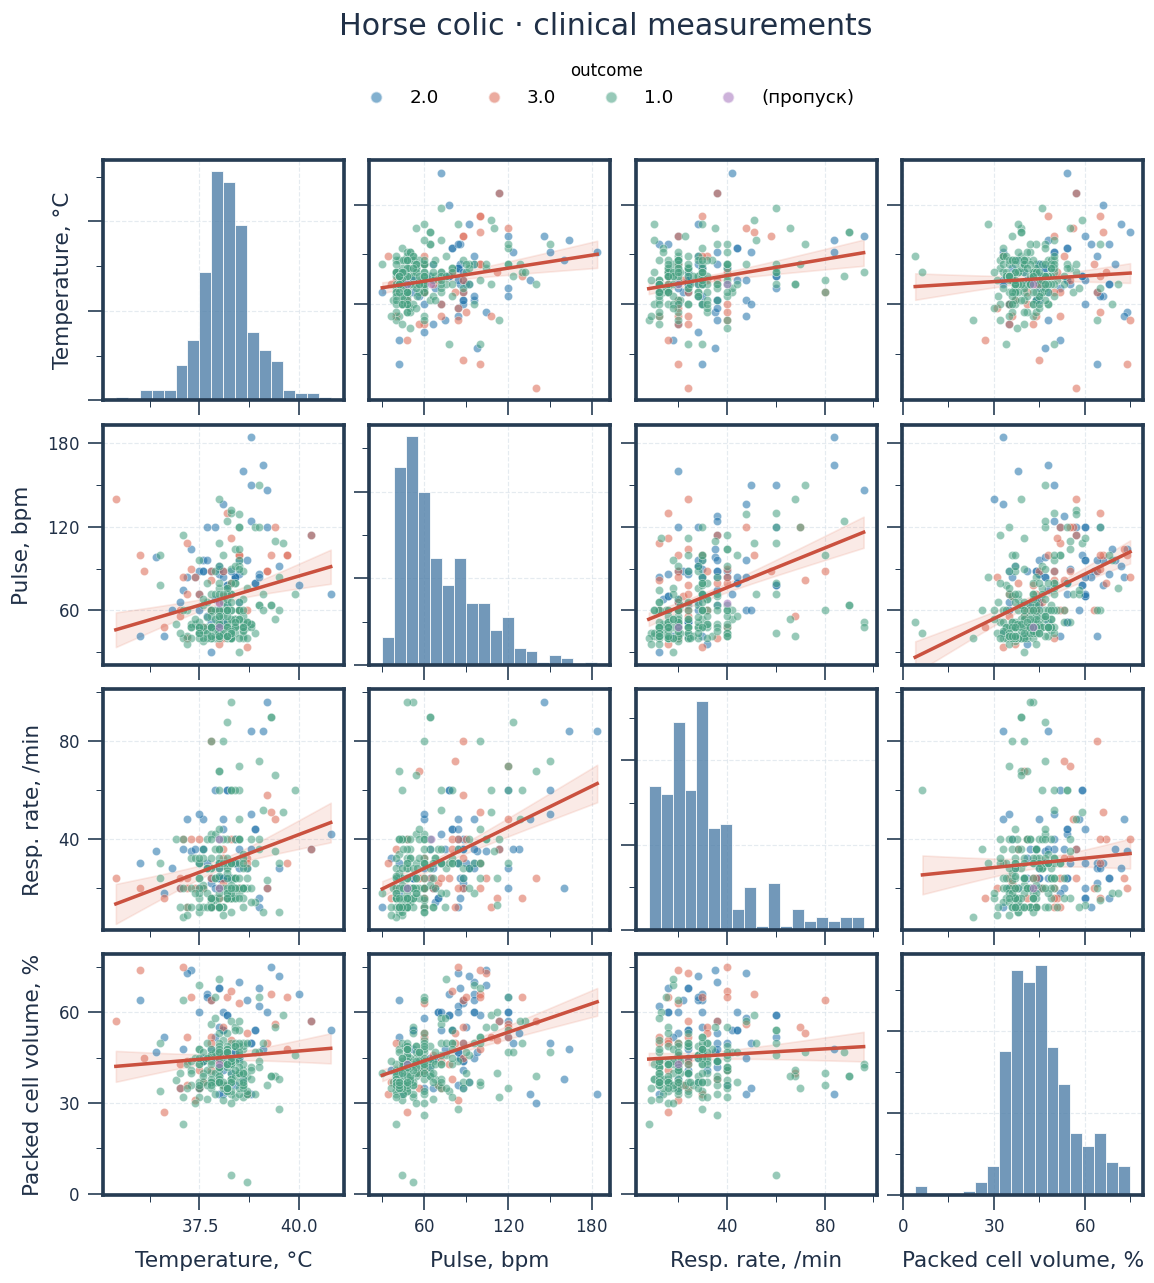

In [3]:
def chosen_scale(values, requested):
    if requested not in ("linear", "log", "symlog", "auto"):
        raise ValueError(f"Неизвестный масштаб: {requested}")
    if requested == "auto":
        magnitudes = np.abs(values[values != 0])
        if len(magnitudes) >= 3:
            q10, q90 = np.quantile(magnitudes, [0.1, 0.9])
            if q90 / max(q10, np.finfo(float).tiny) >= AUTO_SCALE_RATIO:
                requested = "log" if np.all(values > 0) else "symlog"
            else:
                requested = "linear"
        else:
            requested = "linear"
    if requested == "log" and np.any(values <= 0):
        raise ValueError("Логарифмическая ось требует положительных значений; используйте symlog")
    return requested


def set_scale(ax, direction, scale):
    if scale == "linear":
        getattr(ax, f"set_{direction}scale")("linear")
    elif scale == "log":
        getattr(ax, f"set_{direction}scale")("log", base=LOG_BASE)
    else:
        getattr(ax, f"set_{direction}scale")("symlog", base=LOG_BASE, linthresh=SYMLOG_LINTHRESH)


def style_axis(ax, x_name, y_name, row, col, size):
    ax.set_box_aspect(1)
    ax.set_facecolor(FIGURE_COLOR)
    ax.set_axisbelow(True)
    for side, spine in ax.spines.items():
        spine.set_visible(SPINES_VISIBLE[side])
        spine.set_linewidth(SPINE_WIDTH)
        spine.set_color(SPINE_COLOR)
    for direction, name in (("x", x_name), ("y", y_name)):
        axis = getattr(ax, f"{direction}axis")
        scale = scales[name] if direction == "x" or row != col else "linear"
        if scale == "linear":
            axis.set_major_locator(ticker.MaxNLocator(nbins=MAJOR_TICK_COUNT - 1))
            axis.set_minor_locator(ticker.AutoMinorLocator(MINOR_TICK_SUBDIVISIONS)
                                   if MINOR_TICK_SUBDIVISIONS else ticker.NullLocator())
            formatter = ticker.ScalarFormatter(useMathText=True)
            formatter.set_powerlimits((-3, 4))
            formatter.set_useOffset(False)
            axis.set_major_formatter(formatter)
        elif scale == "log":
            axis.set_major_locator(ticker.LogLocator(base=LOG_BASE, numticks=MAJOR_TICK_COUNT))
            axis.set_minor_locator(ticker.LogLocator(base=LOG_BASE, subs=np.arange(2, LOG_BASE))
                                   if MINOR_TICK_SUBDIVISIONS else ticker.NullLocator())
            axis.set_major_formatter(ticker.LogFormatterSciNotation(base=LOG_BASE))
        else:
            axis.set_major_locator(ticker.SymmetricalLogLocator(base=LOG_BASE, linthresh=SYMLOG_LINTHRESH))
            axis.set_minor_locator(ticker.SymmetricalLogLocator(base=LOG_BASE, linthresh=SYMLOG_LINTHRESH,
                                   subs=np.arange(2, LOG_BASE)) if MINOR_TICK_SUBDIVISIONS else ticker.NullLocator())
            axis.set_major_formatter(ticker.LogFormatterSciNotation(base=LOG_BASE, linthresh=SYMLOG_LINTHRESH))
        if name in TICKS_BY_FEATURE and not (direction == "y" and row == col):
            axis.set_major_locator(ticker.FixedLocator(TICKS_BY_FEATURE[name]))
        outer = row == size - 1 if direction == "x" else col == 0
        show_labels = outer and not (direction == "y" and row == col)
        sides = {"top": TICK_TOP, "bottom": True} if direction == "x" else {"left": True, "right": TICK_RIGHT}
        ax.tick_params(axis=direction, which="major", direction=TICK_DIRECTION,
                       length=MAJOR_TICK_LENGTH, width=MAJOR_TICK_WIDTH, pad=TICK_LABEL_PADDING,
                       labelsize=TICK_LABEL_SIZE, colors=SPINE_COLOR, labelcolor=FONT_COLOR,
                       labelrotation=TICK_LABEL_ROTATION, **sides)
        ax.tick_params(axis=direction, which="minor", direction=TICK_DIRECTION,
                       length=MINOR_TICK_LENGTH, width=MINOR_TICK_WIDTH, colors=SPINE_COLOR, **sides)
        ax.tick_params(axis=direction, **({"labelbottom": show_labels} if direction == "x"
                                         else {"labelleft": show_labels}))
        axis.get_offset_text().set_visible(show_labels)
        if outer:
            getattr(ax, f"set_{direction}label")(LABELS_BY_FEATURE.get(name, name),
                fontsize=LABEL_SIZE, color=FONT_COLOR, labelpad=9)
    if MAJOR_GRID:
        ax.grid(True, which="major", color=GRID_COLOR, linewidth=GRID_WIDTH,
                alpha=GRID_ALPHA, linestyle=GRID_STYLE)
    if MINOR_GRID:
        ax.grid(True, which="minor", color=MINOR_GRID_COLOR, linewidth=0.4,
                alpha=0.6, linestyle=":")


def plot_regression(ax, x, y, x_name, y_name):
    pair = (y_name, x_name)
    if not DRAW_REGRESSION or len(x) < 3:
        return
    options = {"confidence": CONFIDENCE, "interval_kind": INTERVAL_KIND,
               "fit_space": FIT_SPACE, "line_color": LINE_COLOR,
               "line_width": LINE_WIDTH, "line_style": LINE_STYLE,
               "band_color": BAND_COLOR, "band_alpha": BAND_ALPHA}
    options.update(PAIR_OPTIONS.get(pair, {}))
    if options["interval_kind"] not in ("mean", "prediction", "none"):
        raise ValueError("interval_kind: mean, prediction или none")
    if options["fit_space"] not in ("data", "axes"):
        raise ValueError("fit_space: data или axes")
    transform_x, transform_y = ax.xaxis.get_transform(), ax.yaxis.get_transform()
    tx = np.asarray(transform_x.transform(x))
    ty = np.asarray(transform_y.transform(y))
    fit_x, fit_y = (tx, ty) if options["fit_space"] == "axes" else (x, y)
    if np.ptp(fit_x) <= 0:
        return
    model = deepcopy(REGRESSION_MODELS.get(pair, LinearRegression())).fit(fit_x, fit_y)
    x_grid = transform_x.inverted().transform(np.linspace(tx.min(), tx.max(), REGRESSION_POINTS))
    model_x = transform_x.transform(x_grid) if options["fit_space"] == "axes" else x_grid
    predicted = np.asarray(model.predict(model_x), float)
    if options["fit_space"] == "axes":
        predicted = transform_y.inverted().transform(predicted)
    if predicted.shape != x_grid.shape or not np.isfinite(predicted).all():
        raise ValueError(f"Модель {pair} вернула некорректные предсказания")
    ax.plot(x_grid, predicted, color=options["line_color"], linewidth=options["line_width"],
            linestyle=options["line_style"], zorder=4)
    if pair in CUSTOM_BANDS:
        band_x, lower, upper = (np.asarray(a, float) for a in CUSTOM_BANDS[pair])
    elif options["interval_kind"] != "none":
        bounds = model.interval(model_x, options["confidence"], options["interval_kind"])
        if bounds is None:
            return
        lower, upper = (np.asarray(a, float) for a in bounds)
        band_x = x_grid
        if options["fit_space"] == "axes":
            lower, upper = transform_y.inverted().transform(lower), transform_y.inverted().transform(upper)
    else:
        return
    if (band_x.ndim != 1 or len(band_x) < 2 or band_x.shape != lower.shape or band_x.shape != upper.shape
            or not all(np.isfinite(a).all() for a in (band_x, lower, upper)) or np.any(lower > upper)):
        raise ValueError(f"Интервал {pair}: x/lower/upper должны быть конечными массивами одной длины; lower <= upper")
    order = np.argsort(band_x)
    band_x, lower, upper = band_x[order], lower[order], upper[order]
    if scales[x_name] == "log" and np.any(band_x <= 0):
        raise ValueError(f"Интервал {pair} имеет неположительный x на логарифмической оси")
    visible = np.ones(len(band_x), bool)
    if scales[y_name] == "log":
        visible = lower > 0
        if not visible.all():
            warnings.warn(f"Интервал {pair}: неположительные границы скрыты на логарифмической оси")
    ax.fill_between(band_x, lower, upper, where=visible,
                    color=options["band_color"], alpha=options["band_alpha"], zorder=2)


def plot_matrix(frame):
    if not FEATURES or len(set(FEATURES)) != len(FEATURES):
        raise ValueError("FEATURES должен содержать уникальные названия признаков")
    if HUE is not None and HUE not in frame:
        raise ValueError(f"Колонка HUE не найдена: {HUE}")
    if not 0 < CONFIDENCE < 1:
        raise ValueError("CONFIDENCE должен быть между 0 и 1")
    if HIST_BINS < 1 or REGRESSION_POINTS < 2 or LOG_BASE <= 1 or SYMLOG_LINTHRESH <= 0:
        raise ValueError("Проверьте HIST_BINS, REGRESSION_POINTS, LOG_BASE и SYMLOG_LINTHRESH")
    if DIAGONAL not in ("hist", "label", "none"):
        raise ValueError("DIAGONAL: hist, label или none")
    global scales
    arrays, scales = {}, {}
    for name in FEATURES:
        if name not in frame:
            raise ValueError(f"Колонка не найдена: {name}")
        try:
            arrays[name] = pd.to_numeric(frame[name], errors="raise").to_numpy(dtype=float, na_value=np.nan)
        except (ValueError, TypeError) as exc:
            raise ValueError(f"Признак {name} должен быть числовым") from exc
        finite = arrays[name][np.isfinite(arrays[name])]
        if not len(finite):
            raise ValueError(f"В признаке {name} нет конечных значений")
        scales[name] = chosen_scale(finite, SCALE_BY_FEATURE.get(name, SCALE))
    groups = [(None, np.ones(len(frame), bool))]
    if HUE is not None:
        groups = [(value, frame[HUE].eq(value).fillna(False).to_numpy(bool))
                  for value in pd.unique(frame[HUE].dropna())]
        if frame[HUE].isna().any():
            groups.append((None, frame[HUE].isna().to_numpy(bool)))
    size = len(FEATURES)
    with plt.rc_context({"font.family": FONT_FAMILY, "font.stretch": FONT_STRETCH}):
        fig, axes = plt.subplots(size, size, figsize=(PANEL_SIZE * size, PANEL_SIZE * size),
                                 dpi=FIGURE_DPI, squeeze=False)
        try:
            fig.set_facecolor(FIGURE_COLOR)
            fig.subplots_adjust(wspace=PANEL_GAP, hspace=PANEL_GAP)
            for row, y_name in enumerate(FEATURES):
                for col, x_name in enumerate(FEATURES):
                    ax = axes[row, col]
                    set_scale(ax, "x", scales[x_name])
                    set_scale(ax, "y", "linear" if row == col else scales[y_name])
                    x, y = arrays[x_name], arrays[y_name]
                    if row == col:
                        if DIAGONAL == "hist":
                            values = x[np.isfinite(x)]
                            transform = ax.xaxis.get_transform()
                            stretched = transform.transform(values)
                            lo, hi = stretched.min(), stretched.max()
                            if lo == hi:
                                lo, hi = lo - 0.5, hi + 0.5
                            bins = transform.inverted().transform(np.linspace(lo, hi, HIST_BINS + 1))
                            ax.hist(values, bins=bins, color=HIST_COLOR, alpha=HIST_ALPHA,
                                    edgecolor=HIST_EDGE_COLOR, linewidth=HIST_EDGE_WIDTH)
                        elif DIAGONAL == "label":
                            ax.text(0.5, 0.5, LABELS_BY_FEATURE.get(x_name, x_name), transform=ax.transAxes,
                                    ha="center", va="center", color=FONT_COLOR, fontsize=LABEL_SIZE + 3)
                    else:
                        finite = np.isfinite(x) & np.isfinite(y)
                        for index, (value, group_mask) in enumerate(groups):
                            style = {"color": PALETTE[index % len(PALETTE)] if HUE else SCATTER_COLOR,
                                     "marker": SCATTER_MARKER, "size": SCATTER_SIZE, "alpha": SCATTER_ALPHA}
                            style.update(GROUP_STYLES.get(value, {}))
                            mask = finite & group_mask
                            ax.scatter(x[mask], y[mask], c=style["color"], marker=style["marker"],
                                       s=style["size"], alpha=style["alpha"],
                                       edgecolors=SCATTER_EDGE_COLOR, linewidths=SCATTER_EDGE_WIDTH,
                                       rasterized=True, zorder=3)
                        plot_regression(ax, x[finite], y[finite], x_name, y_name)
                    style_axis(ax, x_name, y_name, row, col, size)

            limits = {}
            for name in FEATURES:
                if name in LIMITS_BY_FEATURE:
                    limits[name] = LIMITS_BY_FEATURE[name]
                else:
                    values = arrays[name][np.isfinite(arrays[name])]
                    transform = axes[FEATURES.index(name), FEATURES.index(name)].xaxis.get_transform()
                    tv = transform.transform(values)
                    lo, hi = tv.min(), tv.max()
                    pad = (hi - lo) * AXIS_MARGIN if hi > lo else max(abs(lo) * 0.05, 0.5)
                    limits[name] = transform.inverted().transform([lo - pad, hi + pad])
                lo, hi = limits[name]
                if not np.isfinite([lo, hi]).all() or lo >= hi or (scales[name] == "log" and lo <= 0):
                    raise ValueError(f"Неверные пределы оси {name}: {limits[name]}")
            for row, y_name in enumerate(FEATURES):
                for col, x_name in enumerate(FEATURES):
                    axes[row, col].set_xlim(limits[x_name])
                    if row != col:
                        axes[row, col].set_ylim(limits[y_name])
            if TITLE:
                fig.suptitle(TITLE, fontsize=TITLE_SIZE, color=FONT_COLOR, y=0.99)
            if HUE is not None and LEGEND:
                handles = []
                for index, (value, _) in enumerate(groups):
                    style = {"color": PALETTE[index % len(PALETTE)], "marker": SCATTER_MARKER,
                             "alpha": SCATTER_ALPHA}
                    style.update(GROUP_STYLES.get(value, {}))
                    handles.append(Line2D([], [], linestyle="none", marker=style["marker"],
                                          color=style["color"], alpha=style["alpha"],
                                          markeredgecolor=SCATTER_EDGE_COLOR, markersize=LEGEND_MARKER_SIZE,
                                          label="(пропуск)" if value is None else str(value)))
                fig.legend(handles=handles, title=HUE, loc="upper center", bbox_to_anchor=(0.5, 0.965),
                           ncol=LEGEND_COLUMNS, fontsize=LEGEND_FONT_SIZE, frameon=False)
            if OUTPUT_FILE:
                output = Path(OUTPUT_FILE)
                output.parent.mkdir(parents=True, exist_ok=True)
                fig.savefig(output, dpi=SAVE_DPI, bbox_inches="tight", pad_inches=0.16,
                            transparent=TRANSPARENT)
                print(f"Сохранено: {output.resolve()}")
            print("Масштабы:", ", ".join(f"{key}={value}" for key, value in scales.items()))
            if SHOW_PLOT:
                plt.show()
            return fig, axes
        except Exception:
            plt.close(fig)
            raise


frame = pd.read_csv(DATA_FILE)
fig, axes = plot_matrix(frame)
